In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
def ma_model(epsilon_prev, const, theta, sigma2):
    """ X_t = const + epsilon_t + theta * epsilon_{t-1} """

    epsilon_t = np.random.normal(loc=0, scale=np.sqrt(sigma2))
    next_logr = const + epsilon_t + theta * epsilon_prev

    return next_logr

In [12]:
price = pd.read_csv('../data/raw/round_0/prices_round_0_day_-2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_resin = price[price['product'] == 'RAINFOREST_RESIN']
price_kelp = price[price['product'] == 'KELP']

In [13]:
trades = pd.read_csv('../data/raw/round_0/trades_round_0_day_-2_nn.csv', delimiter=';').drop(columns=['buyer', 'seller', 'currency'])
trades_resin = trades[trades['symbol'] == 'RAINFOREST_RESIN']
trades_kelp = trades[trades['symbol'] == 'KELP']

# Resin

In [14]:
price_resin

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
0,0,RAINFOREST_RESIN,10002,1,9996.0,2.0,9995.0,29.0,10004,2,10005.0,29.0,NaN,NaN,10003.0
3,100,RAINFOREST_RESIN,9996,2,9995.0,22.0,NaN,NaN,10004,2,10005.0,22.0,NaN,NaN,10000.0
4,200,RAINFOREST_RESIN,9995,20,NaN,NaN,NaN,NaN,10005,20,NaN,NaN,NaN,NaN,10000.0
7,300,RAINFOREST_RESIN,9996,2,9995.0,29.0,NaN,NaN,10004,2,10005.0,29.0,NaN,NaN,10000.0
8,400,RAINFOREST_RESIN,9996,2,9995.0,25.0,NaN,NaN,10004,2,10005.0,25.0,NaN,NaN,10000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3991,199500,RAINFOREST_RESIN,10002,1,9996.0,1.0,9995.0,22.0,10004,1,10005.0,22.0,NaN,NaN,10003.0
3993,199600,RAINFOREST_RESIN,9996,1,9995.0,21.0,NaN,NaN,10002,7,10004.0,1.0,10005.0,21.0,9999.0
3994,199700,RAINFOREST_RESIN,9998,8,9996.0,2.0,9995.0,25.0,10004,2,10005.0,25.0,NaN,NaN,10001.0
3996,199800,RAINFOREST_RESIN,9995,21,NaN,NaN,NaN,NaN,10002,8,10005.0,21.0,NaN,NaN,9998.5


In [38]:
price_resin.iloc[:500].index

Index([  0,   3,   4,   7,   8,  11,  12,  15,  16,  19,
       ...
       981, 982, 984, 987, 989, 990, 992, 995, 997, 998],
      dtype='int64', length=500)

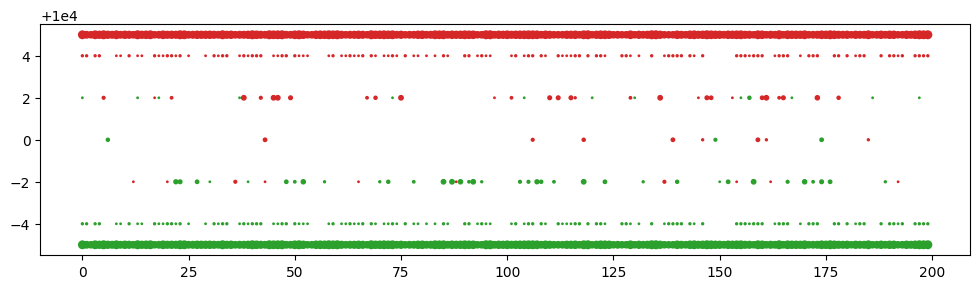

In [46]:
plt.figure(figsize=(12, 3))
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['bid_price_1'], s=price_resin.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['bid_price_2'], s=price_resin.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['bid_price_3'], s=price_resin.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['ask_price_1'], s=price_resin.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['ask_price_2'], s=price_resin.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_resin.iloc[:200]['timestamp']//100, price_resin.iloc[:200]['ask_price_3'], s=price_resin.iloc[:200]['ask_volume_3'], c='tab:red')
plt.show()

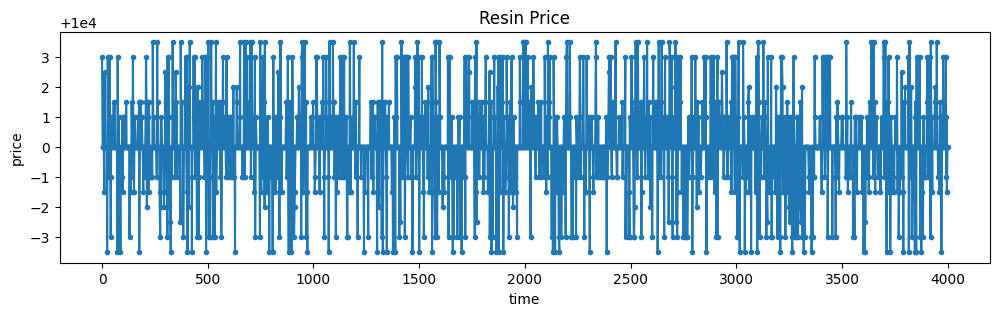

In [28]:
plt.figure(figsize=(12, 3))
plt.plot(price_resin['mid_price'], marker='.')
plt.title('Resin Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [6]:
trades_resin.head()

,timestamp,symbol,price,quantity
2,0,RAINFOREST_RESIN,10004,1
3,1100,RAINFOREST_RESIN,9996,2
5,1700,RAINFOREST_RESIN,10002,1
6,1800,RAINFOREST_RESIN,10002,1
8,2000,RAINFOREST_RESIN,9998,1


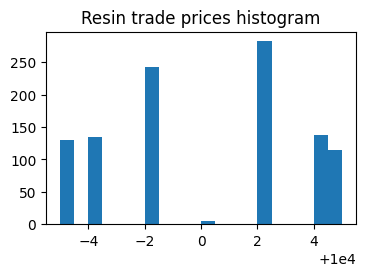

In [7]:
plt.figure(figsize=(4, 2.5))
plt.hist(trades_resin['price'], bins=20, weights=trades_resin['quantity'])
plt.title('Resin trade prices histogram')
plt.show()

# Kelp

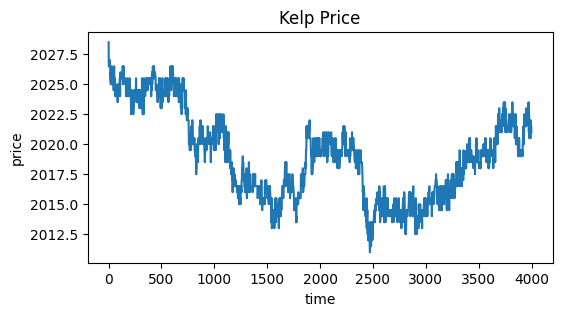

In [7]:
plt.figure(figsize=(6, 3))
plt.plot(price_kelp['mid_price'])
plt.title('Kelp Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [8]:
price_kelp.head()

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
1,0,KELP,2028,1,2026.0,2.0,2025.0,29.0,2029,31,NaN,NaN,NaN,NaN,2028.5
2,100,KELP,2025,24,NaN,NaN,NaN,NaN,2028,2,2029.0,22.0,NaN,NaN,2026.5
5,200,KELP,2025,22,NaN,NaN,NaN,NaN,2028,20,NaN,NaN,NaN,NaN,2026.5
6,300,KELP,2025,31,NaN,NaN,NaN,NaN,2028,2,2029.0,29.0,NaN,NaN,2026.5
9,400,KELP,2025,27,NaN,NaN,NaN,NaN,2028,27,NaN,NaN,NaN,NaN,2026.5


In [9]:
trades_kelp.head()

,timestamp,symbol,price,quantity
0,0,KELP,2029,13
1,0,KELP,2029,1
4,1700,KELP,2026,8
7,1900,KELP,2026,1
9,2400,KELP,2025,1


## Price prediction - mid price

In [72]:
kelp_mid_prices = price_kelp['mid_price'].to_numpy()

train = kelp_mid_prices[:1000]
test = kelp_mid_prices[1000:]

train_logr = np.log(train[1:] / train[:-1])
test_logr = np.log(test[1:] / test[:-1])

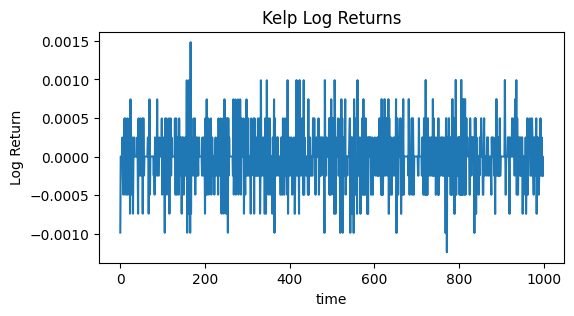

In [73]:
plt.figure(figsize=(6, 3))
plt.plot(train_logr)
plt.title('Kelp Log Returns')
plt.xlabel('time')
plt.ylabel('Log Return')
plt.show()

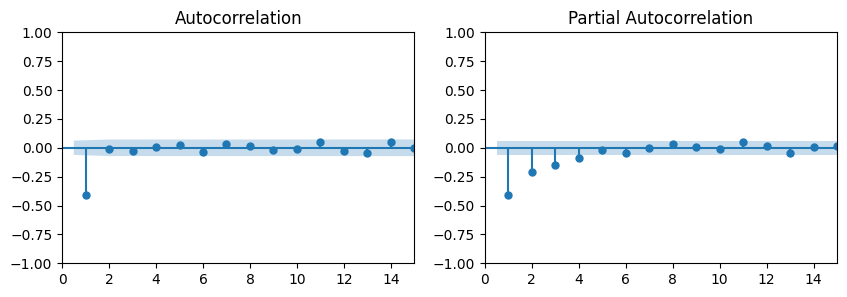

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

- the PACF is exponentially decaying or sinusoidal;
- there is a significant spike at lag q=1 in the ACF, but none beyond lag q=1.
- -> ARIMA(0,1,1) or MA(1)

### Naive

In [102]:
y = test[1:]
y_pred = test[:-1]
err = y - y_pred
rmse = np.mean(err ** 2) ** 0.5
print(rmse)

0.8091073196150524


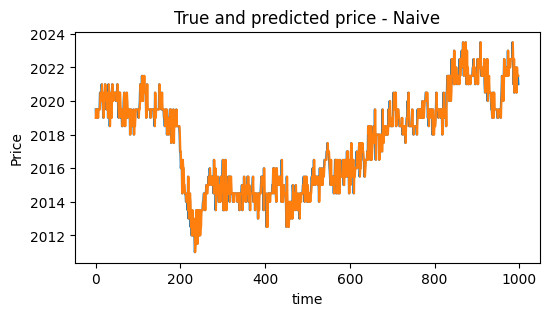

In [103]:
plt.figure(figsize=(6, 3))
plt.plot(y)
plt.plot(y_pred)
plt.title('True and predicted price - Naive')
plt.xlabel('time')
plt.ylabel('Price')
plt.show()

### MA(1)

In [76]:
model = ARIMA(train_logr, order=(0, 0, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(0, 0, 1)   Log Likelihood                6606.102
Date:                Sun, 06 Apr 2025   AIC                         -13206.204
Time:                        16:00:35   BIC                         -13191.484
Sample:                             0   HQIC                        -13200.609
                                - 999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.451e-06   4.83e-06     -0.922      0.356   -1.39e-05    5.01e-06
ma.L1         -0.5338      0.026    -20.701      0.000      -0.584      -0.483
sigma2      1.059e-07   4.22e-09     25.113      0.0

C:\Users\aeali\PycharmProjects\imc-prosperity-3\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [77]:
result.params

array([-4.45109874e-06, -5.33766150e-01,  1.05904036e-07])

In [78]:
errs = [test_logr[0] - 0]
preds = [0]
for i in range(1, len(test_logr)):
    pred = ma_model(epsilon_prev=errs[i-1], const=result.params[0], theta=result.params[1], sigma2=result.params[2])
    err = test_logr[i] - pred
    preds.append(pred)
    errs.append(err)

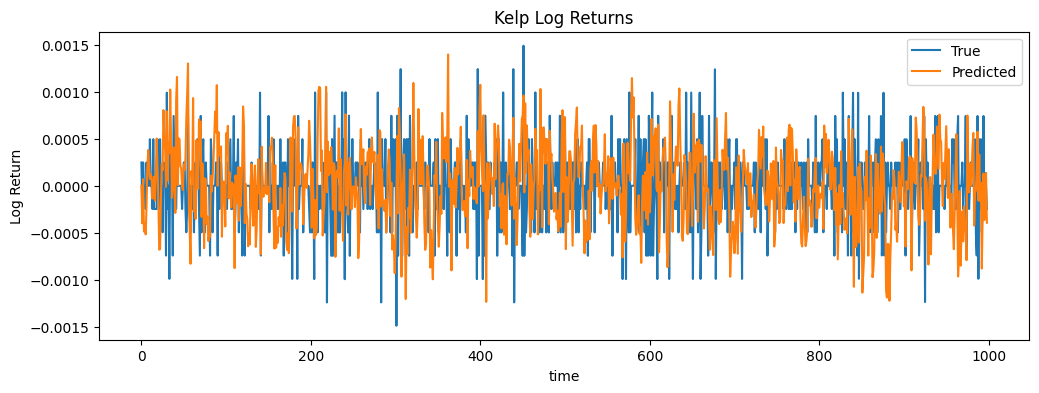

In [95]:
plt.figure(figsize=(12, 4))
plt.plot(test_logr, label='True')
plt.plot(preds, label='Predicted')
plt.title('Kelp Log Returns')
plt.xlabel('time')
plt.ylabel('Log Return')
plt.legend()
plt.show()

In [97]:
len(preds), len(test_logr), len(test)

(999, 999, 1000)

In [98]:
pred_price = test[:-1] * np.exp(preds)

In [104]:
err = test[1:] - pred_price
rmse = np.mean(err ** 2) ** 0.5
print(rmse)

1.0258720227250706


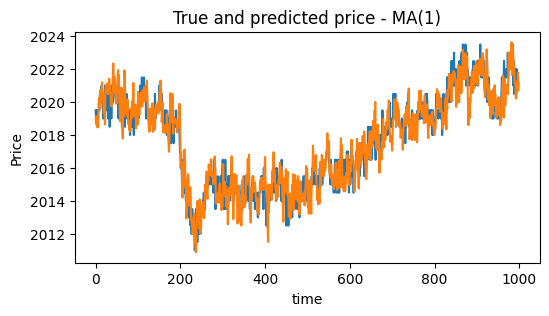

In [100]:
plt.figure(figsize=(6, 3))
plt.plot(test[1:])
plt.plot(pred_price)
plt.title('True and predicted price - MA(1)')
plt.xlabel('time')
plt.ylabel('Price')
plt.show()